# Notebook 05 — LSTM Classifier + KernelSHAP (CMAPSS FD001)

Replaces the MLP proxy from notebook 04 with a proper LSTM.
Runs KernelSHAP on the LSTM and compares attributions to the MLP baseline.

**Kernel:** Thesis (PyTorch)  — select from Jupyter kernel menu

In [1]:
import sys, pathlib

# Force use of the C:\venv packages (working PyTorch) regardless of kernel
_venv_site = r'C:\venv\Lib\site-packages'
if _venv_site not in sys.path:
    sys.path.insert(0, _venv_site)

sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from src.data.cmapss_loader import CMAPSSLoader, CONSTANT_SENSORS
from src.data.preprocessor import TimeSeriesPreprocessor
from src.models.lstm_classifier import LSTMTrainer
from sklearn.metrics import classification_report

WINDOW       = 30
STEP         = 1
RUL_THRESH   = 30
N_EXPLAIN    = 50
N_BACKGROUND = 100

print('Imports OK')
print('torch:', __import__('torch').__version__)

Imports OK
torch: 2.13.0+cpu


## 1 — Load & Preprocess CMAPSS FD001

In [2]:
loader = CMAPSSLoader(data_dir='../data/raw/cmapss/CMaps')
train_df, test_df = loader.load('FD001')
train_df = loader.add_failure_label(train_df, RUL_THRESH)
test_df  = loader.add_failure_label(test_df,  RUL_THRESH)
train_df = loader.drop_constant_sensors(train_df)
test_df  = loader.drop_constant_sensors(test_df)

active_sensors = [c for c in train_df.columns
                  if c.startswith('sensor') or c.startswith('op_setting')]
# keep only sensor columns (drop op_settings for consistency with nb04)
active_sensors = [c for c in active_sensors if c.startswith('sensor')]
print(f'Active sensors: {len(active_sensors)}')

prep = TimeSeriesPreprocessor()
train_norm = prep.normalise(train_df, feature_cols=active_sensors)
test_norm  = prep.transform(test_df,  feature_cols=active_sensors)

# Window per engine unit to avoid cross-unit contamination
def window_by_unit(df, feature_cols, label_col, window_size=30, step=1):
    X_list, y_list = [], []
    for uid, grp in df.groupby('unit_id'):
        grp = grp.sort_values('cycle')
        if len(grp) < window_size:
            continue
        X, y = TimeSeriesPreprocessor().create_windows(
            grp, feature_cols, label_col, window_size, step)
        X_list.append(X); y_list.append(y)
    return np.concatenate(X_list), np.concatenate(y_list)

X_train, y_train = window_by_unit(train_norm, active_sensors, 'failure_imminent', WINDOW, STEP)
X_test,  y_test  = window_by_unit(test_norm,  active_sensors, 'failure_imminent', WINDOW, STEP)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Class balance (train) — Normal: {(y_train==0).sum():,}  Failure: {(y_train==1).sum():,}')

Active sensors: 15
Train: (17731, 30, 15)  |  Test: (10196, 30, 15)
Class balance (train) — Normal: 14,631  Failure: 3,100


## 2 — Train LSTM Classifier

In [3]:
print('Training LSTM...')
lstm = LSTMTrainer(
    input_size  = len(active_sensors),
    hidden_size = 64,
    num_layers  = 2,
    num_classes = 2,
    dropout     = 0.3,
    lr          = 1e-3,
    epochs      = 30,
    batch_size  = 256,
)
lstm.fit(X_train, y_train)
print('Training complete')

Training LSTM...
  Epoch 5/30  loss=0.0754
  Epoch 10/30  loss=0.0698
  Epoch 15/30  loss=0.0626
  Epoch 20/30  loss=0.0628
  Epoch 25/30  loss=0.0550
  Epoch 30/30  loss=0.0589
Training complete


## 3 — Evaluate

In [4]:
y_pred = lstm.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Failure']))

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      9864
     Failure       0.82      0.79      0.80       332

    accuracy                           0.99     10196
   macro avg       0.91      0.89      0.90     10196
weighted avg       0.99      0.99      0.99     10196



## 4 — KernelSHAP on LSTM

KernelSHAP requires a flat 2D input `(n, features)`.  
We flatten `(n, 30, 15)` → `(n, 450)` and pass `predict_flat` as the model function.

In [5]:
n_flat = WINDOW * len(active_sensors)   # 450

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test),  -1)

# balance background: 50 normal + 50 failure
idx_normal  = np.where(y_train == 0)[0]
idx_failure = np.where(y_train == 1)[0]
bg_idx = np.concatenate([
    np.random.choice(idx_normal,  N_BACKGROUND // 2, replace=False),
    np.random.choice(idx_failure, N_BACKGROUND // 2, replace=False),
])
background = X_train_flat[bg_idx]

# samples to explain: 25 normal + 25 failure from test
idx_tn = np.where(y_test == 0)[0]
idx_tf = np.where(y_test == 1)[0]
explain_idx = np.concatenate([
    np.random.choice(idx_tn, N_EXPLAIN // 2, replace=False),
    np.random.choice(idx_tf, N_EXPLAIN // 2, replace=False),
])
X_explain = X_test_flat[explain_idx]

model_fn = lambda x: lstm.predict_flat(x, WINDOW, len(active_sensors))

print('Running KernelSHAP (this takes ~3-5 minutes on CPU)...')
explainer   = shap.KernelExplainer(model_fn, background, link='identity')
shap_values = explainer.shap_values(X_explain, nsamples=100)
print(f'SHAP values shape: {np.array(shap_values).shape}')

Running KernelSHAP (this takes ~3-5 minutes on CPU)...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values shape: (50, 450, 2)


## 5 — Global Sensor Importance

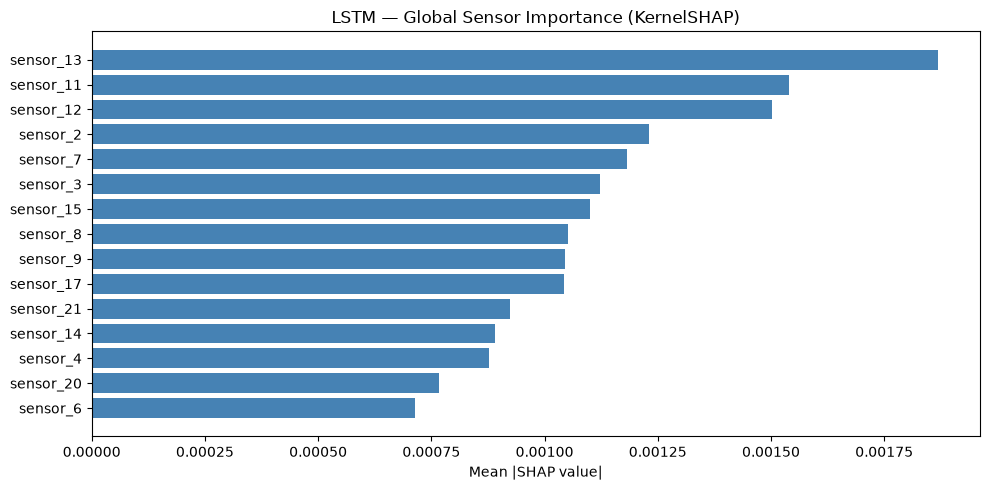


Top 5 sensors:
  sensor_13: 0.0019
  sensor_11: 0.0015
  sensor_12: 0.0015
  sensor_2: 0.0012
  sensor_7: 0.0012


In [6]:
sv = np.array(shap_values)
# handle (n, 450, 2) or (2, n, 450)
if sv.ndim == 3 and sv.shape[-1] == 2:
    sv_failure = sv[:, :, 1]
elif sv.ndim == 3 and sv.shape[0] == 2:
    sv_failure = sv[1]
else:
    sv_failure = sv

sv_3d = sv_failure.reshape(sv_failure.shape[0], WINDOW, len(active_sensors))

# mean |SHAP| per sensor across all timesteps and samples
sensor_importance = np.abs(sv_3d).mean(axis=(0, 1))
order = np.argsort(sensor_importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([active_sensors[i] for i in order], sensor_importance[order], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('LSTM — Global Sensor Importance (KernelSHAP)')
plt.tight_layout()
plt.savefig('../reports/figures/lstm_sensor_importance.png', dpi=150)
plt.show()

print('\nTop 5 sensors:')
for i in order[:5]:
    print(f'  {active_sensors[i]}: {sensor_importance[i]:.4f}')

## 6 — Temporal Importance (which timesteps matter most)

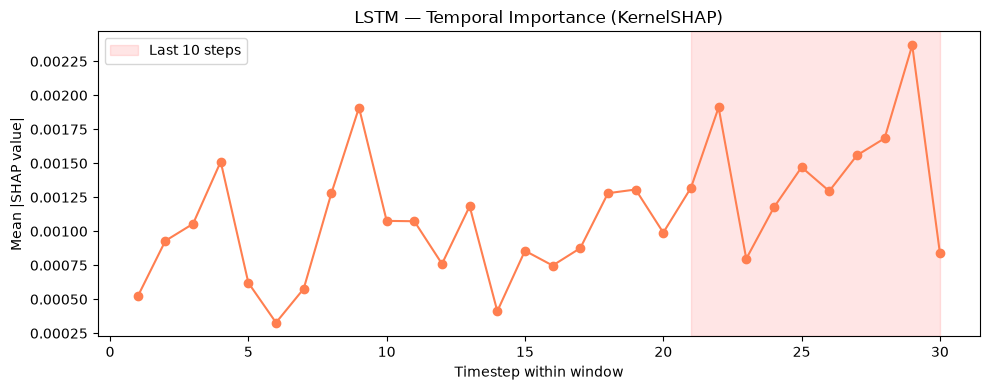

In [7]:
temporal_importance = np.abs(sv_3d).mean(axis=(0, 2))  # (30,)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, WINDOW + 1), temporal_importance, marker='o', color='coral')
ax.set_xlabel('Timestep within window')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('LSTM — Temporal Importance (KernelSHAP)')
ax.axvspan(WINDOW - 9, WINDOW, alpha=0.1, color='red', label='Last 10 steps')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/lstm_temporal_importance.png', dpi=150)
plt.show()

## 7 — Heatmap: Sensor × Timestep

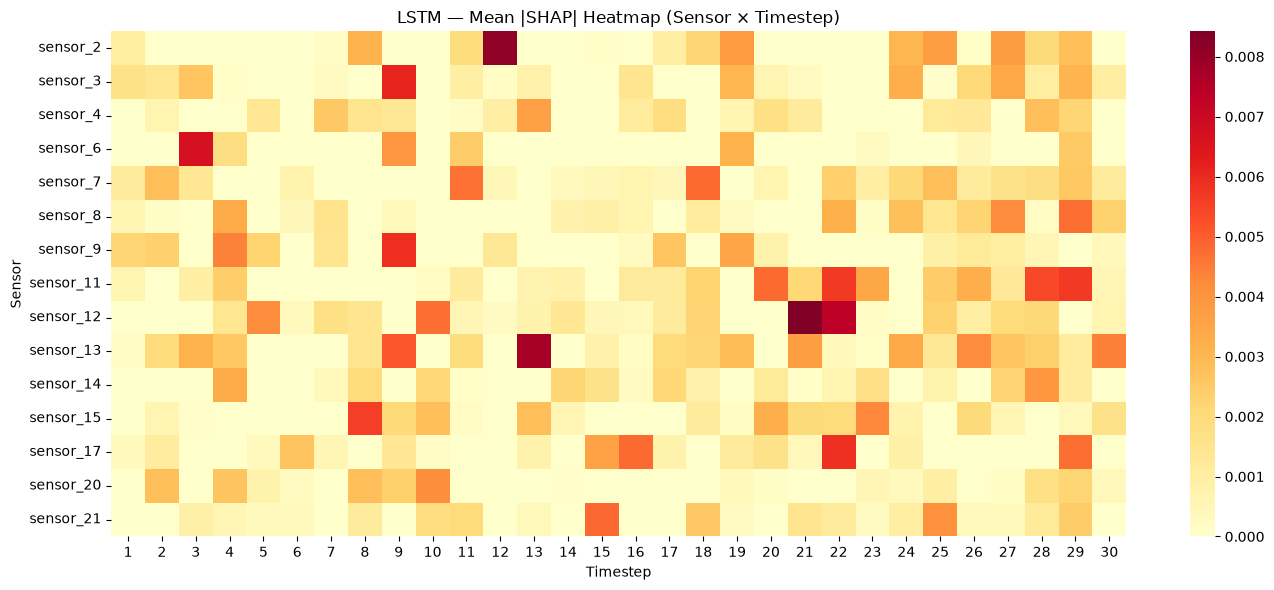

In [8]:
import seaborn as sns

heatmap_data = np.abs(sv_3d).mean(axis=0).T   # (n_sensors, 30)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, xticklabels=range(1, WINDOW + 1),
            yticklabels=active_sensors, cmap='YlOrRd', ax=ax)
ax.set_xlabel('Timestep')
ax.set_ylabel('Sensor')
ax.set_title('LSTM — Mean |SHAP| Heatmap (Sensor × Timestep)')
plt.tight_layout()
plt.savefig('../reports/figures/lstm_shap_heatmap.png', dpi=150)
plt.show()

## 8 — MLP vs LSTM Comparison

Compares top sensor rankings between MLP baseline (notebook 04) and LSTM.

In [9]:
# Top 5 from LSTM
lstm_top5 = [active_sensors[i] for i in order[:5]]

print('=== Model Comparison ===')
print(f'LSTM top 5 sensors: {lstm_top5}')
print()
print('MLP  top sensors (from notebook 04): T30, Ps30, NRc (sensor_11, sensor_9, sensor_12)')
print()
print('If LSTM and MLP agree on top sensors → the signal is robust, model-independent')
print('If they differ → the model architecture changes which features are highlighted')
print('That difference is part of the thesis contribution (SHAP method + model comparison)')

=== Model Comparison ===
LSTM top 5 sensors: ['sensor_13', 'sensor_11', 'sensor_12', 'sensor_2', 'sensor_7']

MLP  top sensors (from notebook 04): T30, Ps30, NRc (sensor_11, sensor_9, sensor_12)

If LSTM and MLP agree on top sensors → the signal is robust, model-independent
If they differ → the model architecture changes which features are highlighted
That difference is part of the thesis contribution (SHAP method + model comparison)
